In [ ]:
import os
import pprint
import argparse
import glob

import torch
import torch.nn as nn
import torch.backends.cudnn as cudnn
from torch.utils.data import DataLoader
import sys
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd())))

import pandas as pd
import numpy as np
import cv2
from matplotlib import pyplot as plt
from scipy.spatial import distance

import matplotlib.pyplot as plt
from matplotlib import font_manager

# Register the Lato font
font_dirs = ['fonts/Lato']
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)
for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# Set the default font to Lato
plt.rcParams['font.family'] = 'Lato'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'  # Bold the title
plt.rcParams['axes.labelweight'] = 'bold'

%matplotlib inline

In [ ]:
os.chdir("Multicentre-Fetal-Biometry")

In [7]:
def analyze_tta(metric, anatomy, predictions, OUTPUT_PNG_DIR, df_for_hrnet, display=True):
    meases = []

    df_for_hrnet.drop(df_for_hrnet.columns[0], axis=1, inplace=True)

    # Remove rows where any landmarks are negative OR NaN (matching dataset filtering)
    # Select correct landmark columns based on anatomy AND metric (matching fetal.py logic)
    if anatomy == 'brain':
        if metric.upper() == 'OFD':
            landmark_cols = df_for_hrnet.columns[4:8]
        elif metric.upper() == 'BPD':
            landmark_cols = df_for_hrnet.columns[8:12]
        else:
            raise ValueError(f"Metric {metric} not supported for brain")
    elif anatomy == 'abdomen':
        if metric.upper() == 'TAD':
            landmark_cols = df_for_hrnet.columns[4:8]
        elif metric.upper() == 'APAD':
            landmark_cols = df_for_hrnet.columns[8:12]
        else:
            raise ValueError(f"Metric {metric} not supported for abdomen")
    elif anatomy == 'femur':
        if metric.upper() == 'FL':
            landmark_cols = df_for_hrnet.columns[4:8]
        else:
            raise ValueError(f"Metric {metric} not supported for femur")
    else:
        raise ValueError(f"Anatomy {anatomy} not supported")

    mask = (df_for_hrnet[landmark_cols] < 0).any(axis=1)
    df_for_hrnet = df_for_hrnet[~mask].reset_index(drop=True)

    for j, elem in df_for_hrnet.iterrows():
        sub_pred = predictions[j].cpu().numpy()
        
        # Attempt to read the image in both .png and .jpeg formats
        image_path = os.path.join(OUTPUT_PNG_DIR, elem["image_name"])
        image = cv2.imread(image_path)
        
        if display:
            plt.figure()
            plt.imshow(image)
            plt.title(elem["image_name"])

        x1_point = int(df_for_hrnet.loc[j,metric.lower()+'_1_x'])
        y1_point = int(df_for_hrnet.loc[j,metric.lower()+'_1_y'] )
        x2_point = int(df_for_hrnet.loc[j,metric.lower()+'_2_x'])
        y2_point = int(df_for_hrnet.loc[j,metric.lower()+'_2_y'] )
        res_pts = sub_pred
        if display:
            plt.title(elem["image_name"], fontsize=18)
            plt.plot( (x1_point, x2_point), (y1_point,y2_point), '#529A21-', label='Ground Truth', linewidth=1.5)
            plt.plot( res_pts[:,0], res_pts[:,1], '#EDC041-', label='Prediction', linewidth=1.5)
        orig_pts = np.array(( (x1_point, x2_point), (y1_point,y2_point)))
        p1, p2 = distance.euclidean(orig_pts.T[0], orig_pts.T[1],) , distance.euclidean(res_pts[0], res_pts[1],)
        pix_size = float(elem["px_to_mm_rate"])
        p1 , p2 = p1 * pix_size, p2*pix_size
        meases.append((p1,p2))#, elem.origalgo))
    return meases


Processing folder: FP

FP - brain - BPD: 0.794333042786434
FP - brain - OFD: 1.3451990987472398
FP - abdomen - TAD: 1.6895951015017476
FP - abdomen - APAD: 2.0533721873508375
FP - femur - FL: 1.089299218979747

Processing folder: UCL

UCL - brain - BPD: 1.6405522849532177
UCL - brain - OFD: 3.452239886640492
UCL - abdomen - TAD: 2.5258189895382954
UCL - abdomen - APAD: 2.287139691667023
UCL - femur - FL: 0.8397405452726937

Processing folder: HC18

HC18 - brain - BPD: 16.217830380308158
HC18 - brain - OFD: 38.70481741181222


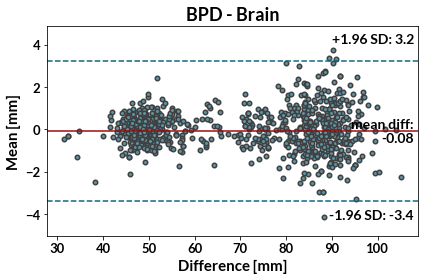

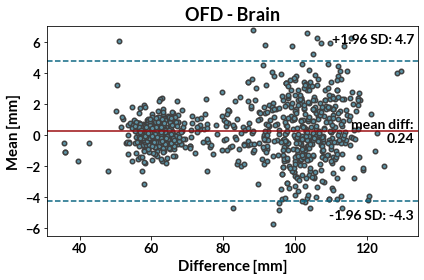

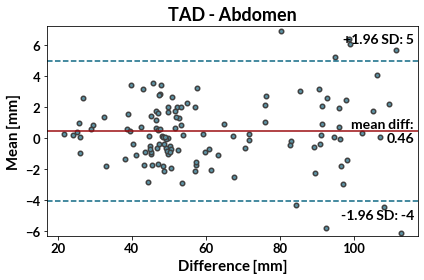

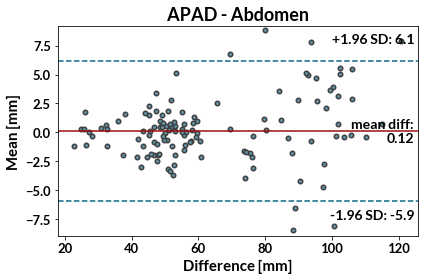

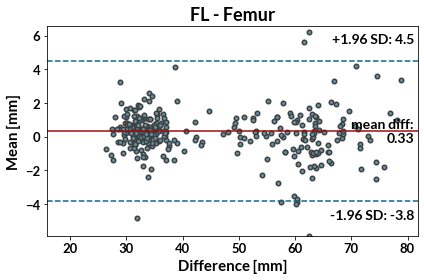

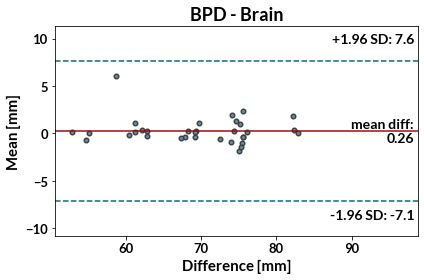

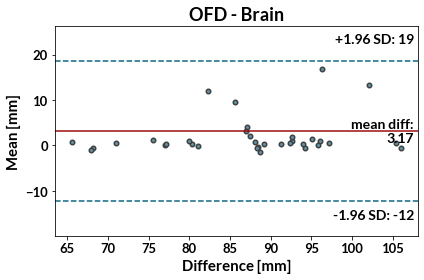

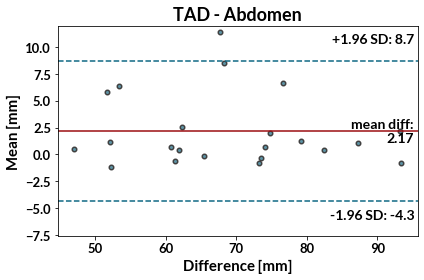

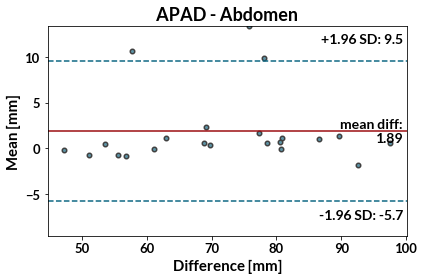

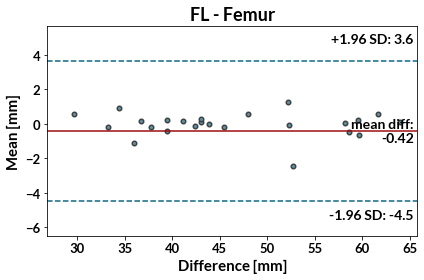

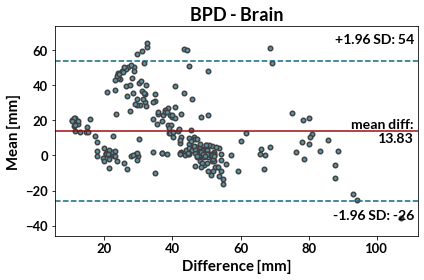

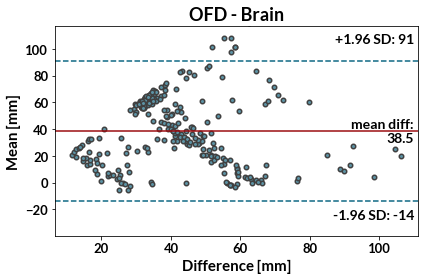

In [ ]:
import statsmodels.api as sm

color_face = '#5D94A6'
color_edge = '#404040'

# Colors for Bland-Altman plot lines
color_mean = '#9b0a0e'  # Red for mean
color_std = '#0c6783'   # Blue/teal for std lines

# Iterate over all folders automatically
folders = ['FP', 'UCL', 'HC18']

for folder in folders:
    print(f"\n{'='*60}")
    print(f"Processing folder: {folder}")
    print(f"{'='*60}\n")
    
    # Define all metrics per anatomy
    if folder == 'FP' or folder == 'UCL':
        anatomy_config = {
            "brain": {"key": "Head", "anatomy": "brain", "metrics": ["bpd", "ofd"]},
            "abdomen": {"key": "Abdomen", "anatomy": "abdomen", "metrics": ["tad", "apad"]},
            "femur": {"key": "Femur", "anatomy": "femur", "metrics": ["fl"]}
        }
        display = False

    else:  # HC18
        anatomy_config = {
            "brain": {"key": "Head", "anatomy": "brain", "metrics": ["bpd", "ofd"]},
        }
        display = False

    # Process each anatomy and its metrics
    for anatomy, config in anatomy_config.items():
        key = config["key"]
        anatomy = config["anatomy"]
        metrics = config["metrics"]
        
        OUTPUT_PNG_DIR = f"output/{folder}/{key}/"

        # if the output folder is not present, create it
        os.makedirs(OUTPUT_PNG_DIR, exist_ok=True)


        for metric in metrics:
            # Load a FRESH copy of the CSV for each metric (important - analyze_tta modifies it!)
            metric = metric.upper()
            
            if folder == 'HC18':
                df_for_hrnet = pd.read_csv(f"data/annotations/{folder}/Head_Test.csv")
            elif folder == 'FP' or folder == 'UCL':
                df_for_hrnet = pd.read_csv(f"data/annotations/{folder}/{key}_Test.csv")
            else:
                raise ValueError(f"Folder {folder} not supported")
            
            # Load the predictions 
            predictions = torch.load(f"output/FETAL/fetal_landmark_hrnet_w18_{folder}_{anatomy}_{metric.upper()}/predictions_on_{folder}.pth")
            results = analyze_tta(metric, anatomy, predictions, OUTPUT_PNG_DIR, df_for_hrnet, display=display)
            
            curr_fig, curr_ax = plt.subplots()
            mmm = np.array(results)
            sm.graphics.mean_diff_plot(mmm[:,0], mmm[:,1], ax=curr_ax)
            print(f"{folder} - {anatomy} - {metric.upper()}: {np.mean(np.abs(mmm[:,0] - mmm[:,1]))}")
            
            # Style the scatter points
            for item in curr_ax.collections:
                item.set_color(color_face)
                item.set_edgecolor(color_edge)
                item.set_linewidth(1.5)  # Edge thickness of circles
            
            # Style the lines (mean and limits of agreement)
            # Line 0: mean difference
            curr_ax.lines[0].set_color(color_mean)
            curr_ax.lines[0].set_linewidth(1.5)
            
            # Lines 1 and 2: limits of agreement (±1.96 SD)
            if len(curr_ax.lines) > 1:
                curr_ax.lines[1].set_color(color_std)
                curr_ax.lines[1].set_linewidth(1.5)
            if len(curr_ax.lines) > 2:
                curr_ax.lines[2].set_color(color_std)
                curr_ax.lines[2].set_linewidth(1.5)
            
            plt.title(f"{metric.upper()} - {anatomy.capitalize()}", fontsize=18)
            plt.xlabel("Mean [mm]")
            plt.ylabel("Difference [mm]")
            plt.tight_layout()
            
            os.makedirs(f"output/FETAL/{folder}_figs", exist_ok=True)
            
            plt.savefig(f"output/FETAL/{folder}_figs/{anatomy.capitalize()}_{metric.upper()}.png", format='png', dpi=600)
            plt.savefig(f"output/FETAL/{folder}_figs/{anatomy.capitalize()}_{metric.upper()}.svg", format='svg')